# Week 2: Data Preprocessing & Feature Engineering Pipeline
 
**objective**: Take a raw messy dataset, clean it, handle missing values, encode categorical variables, scale features, handle outliers, engineer new features, and present a complete before-and-after comparison.  
**dataset files**: uncleaned dataset (137 rows)


## 1. Environment Setup & Import Libraries

In [5]:
%pip install scikit-learn

import os
import re
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

raw_csv_path = 'Unclean Dataset.csv'
cleaned_csv_path = 'Cleaned_Dataset.csv'

print("Libraries imported successfully!")


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


## 2. Raw Data Inspection & Exploration

We begin by loading the raw dataset `Unclean Dataset.csv` and inspecting its formatting, and structural issues.
Noticeable anomalies in the raw data:
- Mixed delimiters: Some rows use `|` (pipe), others use `,` (comma).
- Formatting corruptions: Duplicate row text concatenated with commas (`101 | John... $1200, 101 | John...`).
- Dirty currency values: Currency symbols (`$`, `?`, ``), commas in numbers (`" ?20,000.00 "`).
- Merged columns: Gender and Age merged together (`M 25`, `F 24`).
- Dirty age strings: Asterisks in ages (`78*`, `21*`), extreme outliers (`4`, `78`, `40`).
- Typos in course names: `Machine Learnin`, `Web Develpment`, `Web Developmet`, `Data Analytics`, invalid numeric value `4`.
- Unformatted dates: `2022-05-15`, `05-09-23`, `01-Jul-21`, missing `NA` dates.


In [6]:
with open(raw_csv_path, 'r', encoding='utf-8', errors='ignore') as f:
    raw_lines = [line.strip() for line in f if line.strip()]

print(f"Total non-empty raw lines in CSV file: {len(raw_lines)}")
print("\nFirst 10 raw lines:")
for idx, line in enumerate(raw_lines[:10]):
    print(f"Line {idx}: {line}")


Total non-empty raw lines in CSV file: 137

First 10 raw lines:
Line 0: Student_ID , First_Name , Last_Name , Age , Gender , Course , Enrollment_Date , Total_Payments
Line 1: 101        | John       | Smith     | 22  | M      | Data Science   | 2022-05-15      | $1200,,,,,,,
Line 2: 102        | Emily      | Johnson   | 24  | F      | Machine Learnin| 2022-03-18      | $1400,,,,,,,
Line 3: 103        | Michael    | Williams  | 21  | M      | Data Science   | 2022-06-25      | $900,,,,,,,
Line 4: 104        | Sarah      | Brown     | 23  | F      | Data Science   | NA              | $1100,,,,,,,
Line 5: 105        | David      | Davis     | 20  | M      | Web Developmen | 2021-09-10      | $950,,,,,,,
Line 6: 106        | Jessica    | Miller    | 25  | F      | Machine Learnin| 2022-04-22      | $1300,,,,,,,
Line 7: 107        | Brian      | Wilson    | 19  | M      | Data Science   | 2022-07-02      | $1000,,,,,,,
Line 8: 108        | Amanda     | Taylor    | 22  | F      | Machine Lea

## 3. Custom Raw Ingestion & Parser Pipeline

To handle the mixed pipe (`|`) and comma (`,`) delimiters, concatenated duplicated fields, and merged columns, we build a robust raw parser.


In [7]:
records = []

for idx, line in enumerate(raw_lines):
    if line.startswith('Student_ID'):
        continue
    
    sid, fname, lname, age, gender, course, edate, payment = None, None, None, None, None, None, None, None

    if '|' in line:
        pipe_part = line.split(',')[0]
        parts = [p.strip() for p in pipe_part.split('|')]
        
        if len(parts) > 0 and parts[0] == '':
            if len(parts) >= 8 and (parts[3].isdigit() or parts[4] in ['M', 'F', 'm', 'f']):
                sid = None
                fname, lname, age, gender, course, edate, payment = parts[1:8]
            else:
                parts = parts[1:]
                sid = parts[0] if len(parts) > 0 and parts[0] else None
                fname = parts[1] if len(parts) > 1 and parts[1] else None
                lname = parts[2] if len(parts) > 2 and parts[2] else None
                age = parts[3] if len(parts) > 3 and parts[3] else None
                gender = parts[4] if len(parts) > 4 and parts[4] else None
                course = parts[5] if len(parts) > 5 and parts[5] else None
                edate = parts[6] if len(parts) > 6 and parts[6] else None
                payment = parts[7] if len(parts) > 7 and parts[7] else None
        else:
            sid = parts[0] if len(parts) > 0 and parts[0] else None
            fname = parts[1] if len(parts) > 1 and parts[1] else None
            lname = parts[2] if len(parts) > 2 and parts[2] else None
            age = parts[3] if len(parts) > 3 and parts[3] else None
            gender = parts[4] if len(parts) > 4 and parts[4] else None
            course = parts[5] if len(parts) > 5 and parts[5] else None
            edate = parts[6] if len(parts) > 6 and parts[6] else None
            payment = parts[7] if len(parts) > 7 and parts[7] else None
    else:
        reader = list(csv.reader([line]))
        if not reader:
            continue
        cols = [c.strip() for c in reader[0]]
        if len(cols) >= 8:
            c0, c1, c2, c3, c4, c5, c6, c7 = cols[:8]
            if c0 and not c2:
                name_parts = c0.split()
                if len(name_parts) >= 2:
                    fname = name_parts[0]
                    lname = ' '.join(name_parts[1:])
                else:
                    fname = c0
            else:
                fname = c0 if c0 else c1
                lname = c2 if c2 else None
            
            combined_ag = f"{c3} {c4}".strip()
            g_match = re.search(r'\b([MFmf])\b', combined_ag)
            if g_match:
                gender = g_match.group(1).upper()
            
            a_match = re.search(r'\b(\d+\*?)\b', combined_ag)
            if a_match:
                age = a_match.group(1)
                
            course = c5 if c5 != '' else None
            edate = c6 if c6 != '' else None
            payment = c7 if c7 != '' else None

    records.append({
        'Student_ID': sid,
        'First_Name': fname,
        'Last_Name': lname,
        'Age': age,
        'Gender': gender,
        'Course': course,
        'Enrollment_Date': edate,
        'Total_Payments': payment
    })

df_raw = pd.DataFrame(records)
print(f"Extracted Raw DataFrame Shape: {df_raw.shape}")
print("\nRaw DataFrame Missing Values Count:")
print(df_raw.isnull().sum())
print("\nSample Extracted Raw Data:")
df_raw.head(10)


Extracted Raw DataFrame Shape: (136, 8)

Raw DataFrame Missing Values Count:
Student_ID         63
First_Name          0
Last_Name           5
Age                 2
Gender              1
Course              6
Enrollment_Date     2
Total_Payments      2
dtype: int64

Sample Extracted Raw Data:


,Student_ID,First_Name,Last_Name,Age,Gender,Course,Enrollment_Date,Total_Payments
0,101,John,Smith,22,M,Data Science,2022-05-15,$1200
1,102,Emily,Johnson,24,F,Machine Learnin,2022-03-18,$1400
2,103,Michael,Williams,21,M,Data Science,2022-06-25,$900
3,104,Sarah,Brown,23,F,Data Science,NA,$1100
4,105,David,Davis,20,M,Web Developmen,2021-09-10,$950
5,106,Jessica,Miller,25,F,Machine Learnin,2022-04-22,$1300
6,107,Brian,Wilson,19,M,Data Science,2022-07-02,$1000
7,108,Amanda,Taylor,22,F,Machine Learnin,2022-08-15,$1200
8,109,William,Anderson,24,M,Data Science,2022-01-10,$950
9,110,Olivia,Martinez,26,F,Data Science,2023-02-28,$1150


## 4. Cleaning & Handling Missing (Null) Values

In this step:
1. **Student_ID**: Convert to integer. Missing IDs are assigned unique sequential numbers starting after `max(Student_ID)`.
2. **First_Name & Last_Name**: Clean whitespace, convert to Title Case, fill missing names with `'Unknown'`.
3. **Age**: Remove non-numeric characters (like `*`), convert to float. Impute missing values with the **median age**.
4. **Gender**: Normalize to `'M'` or `'F'`. Impute missing values with the **mode gender**.
5. **Course**: Correct typos (`Web Develpment` -> `Web Development`, `Machine Learnin` -> `Machine Learning`, `Data Analytics` -> `Data Analysis`, invalid `'4'` -> `NaN`). Impute missing with **mode course**.
6. **Enrollment_Date**: Parse all date formats (`YYYY-MM-DD`, `DD-Mon-YY`, etc.) to standard datetime format. Impute missing dates with **mode date**.
7. **Total_Payments**: Strip currency symbols (`$`, `?`, ``, `,`), convert to float. Impute missing payments with **median payment**.


In [8]:
df_clean = df_raw.copy()


print(f"Duplicates before dropping: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Shape after deduplication: {df_clean.shape}")

# 1. Clean Student_ID
df_clean['Student_ID'] = pd.to_numeric(df_clean['Student_ID'], errors='coerce')
max_id = int(df_clean['Student_ID'].max()) if df_clean['Student_ID'].notnull().any() else 100
missing_id_mask = df_clean['Student_ID'].isnull()
df_clean.loc[missing_id_mask, 'Student_ID'] = [max_id + 1 + i for i in range(missing_id_mask.sum())]
df_clean['Student_ID'] = df_clean['Student_ID'].astype(int)

# 2. Clean First_Name & Last_Name
df_clean['First_Name'] = df_clean['First_Name'].fillna('Unknown').astype(str).str.strip().str.title()
df_clean['Last_Name'] = df_clean['Last_Name'].fillna('Unknown').astype(str).str.strip().str.title()

# 3. Clean Age & Impute
def clean_age(val):
    if pd.isnull(val) or val is None: return np.nan
    v_str = re.sub(r'[^\d]', '', str(val))
    return float(v_str) if v_str else np.nan

df_clean['Age'] = df_clean['Age'].apply(clean_age)
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

# 4. Clean Gender & Impute
df_clean['Gender'] = df_clean['Gender'].astype(str).str.upper().str.strip()
df_clean['Gender'] = df_clean['Gender'].replace({'NONE': np.nan, 'NAN': np.nan})
mode_gender = df_clean['Gender'].mode()[0]
df_clean['Gender'] = df_clean['Gender'].fillna(mode_gender)

# 5. Clean Course & Impute
course_map = {
    'Web Develpment': 'Web Development',
    'Web Developmet': 'Web Development',
    'Web Developmen': 'Web Development',
    'Machine Learnin': 'Machine Learning',
    'Data Analytics': 'Data Analysis',
    '4': np.nan
}
df_clean['Course'] = df_clean['Course'].replace(course_map)
mode_course = df_clean['Course'].mode()[0]
df_clean['Course'] = df_clean['Course'].fillna(mode_course)

# 6. Clean Enrollment_Date & Impute
df_clean['Enrollment_Date'] = pd.to_datetime(df_clean['Enrollment_Date'], errors='coerce')
mode_date = df_clean['Enrollment_Date'].mode()[0]
df_clean['Enrollment_Date'] = df_clean['Enrollment_Date'].fillna(mode_date)

# 7. Clean Total_Payments & Impute
def clean_payment(val):
    if pd.isnull(val) or val is None or val == 'NA': return np.nan
    v_str = re.sub(r'[^\d.]', '', str(val))
    return float(v_str) if v_str else np.nan

df_clean['Total_Payments'] = df_clean['Total_Payments'].apply(clean_payment)
median_payment = df_clean['Total_Payments'].median()
df_clean['Total_Payments'] = df_clean['Total_Payments'].fillna(median_payment)

print("\nMissing Values Count After Cleaning & Imputation:")
print(df_clean.isnull().sum())


Duplicates before dropping: 8
Shape after deduplication: (128, 8)

Missing Values Count After Cleaning & Imputation:
Student_ID         0
First_Name         0
Last_Name          0
Age                0
Gender             0
Course             0
Enrollment_Date    0
Total_Payments     0
dtype: int64


## 5. Outlier Detection & Removal / Capping

We utilize the **Interquartile Range (IQR)** method to detect and handle outliers in numerical features (`Age`).
- $Q1$ = 25th Percentile, $Q3$ = 75th Percentile, $IQR = Q3 - Q1$.
- Lower Bound = $Q1 - 1.5 \times IQR$, Upper Bound = $Q3 + 1.5 \times IQR$.
- Outliers such as `Age = 4`, `78`, `40` fall outside normal student ranges and are capped/imputed to the median age.


In [9]:
# Age Outlier Detection using IQR
Q1_age = df_clean['Age'].quantile(0.25)
Q3_age = df_clean['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

print(f"Age IQR Bounds: Lower = {lower_bound_age}, Upper = {upper_bound_age}")

age_outliers_before = df_clean[(df_clean['Age'] < lower_bound_age) | (df_clean['Age'] > upper_bound_age)]
print(f"Detected {len(age_outliers_before)} Age outliers before capping:")
display(age_outliers_before[['Student_ID', 'First_Name', 'Last_Name', 'Age']])

# Capping outliers to median age
df_clean.loc[(df_clean['Age'] < lower_bound_age) | (df_clean['Age'] > upper_bound_age), 'Age'] = median_age

print(f"Age outliers after capping: {((df_clean['Age'] < lower_bound_age) | (df_clean['Age'] > upper_bound_age)).sum()}")


Age IQR Bounds: Lower = 18.0, Upper = 26.0
Detected 3 Age outliers before capping:


,Student_ID,First_Name,Last_Name,Age
36,511,Kylian,Eden,78.0
85,541,Amina,Osagie,40.0
93,549,Nneka,Nwachukwu,4.0


Age outliers after capping: 0


## 6. Feature Engineering (Creating 4 New Features)

We create 4 new engineered features to enhance the dataset for downstream modeling and analysis:
1. `Full_Name`: Concatenated `First_Name` + `' '` + `Last_Name`.
2. `Enrollment_Year`: Extracted Year from `Enrollment_Date`.
3. `Enrollment_Month`: Extracted Month Name from `Enrollment_Date`.
4. `Payment_Tier`: Categorical binning of `Total_Payments` into 3 quantiles (`Low`, `Medium`, `High`).


In [10]:

df_clean['Full_Name'] = df_clean['First_Name'] + ' ' + df_clean['Last_Name']

df_clean['Enrollment_Year'] = df_clean['Enrollment_Date'].dt.year

df_clean['Enrollment_Month'] = df_clean['Enrollment_Date'].dt.month_name()

df_clean['Payment_Tier'] = pd.qcut(df_clean['Total_Payments'], q=3, labels=['Low', 'Medium', 'High'])

print("Engineered Features Sample:")
df_clean[['Full_Name', 'Enrollment_Year', 'Enrollment_Month', 'Payment_Tier']].head(10)


Engineered Features Sample:


,Full_Name,Enrollment_Year,Enrollment_Month,Payment_Tier
0,John Smith,2022,May,Low
1,Emily Johnson,2022,March,Medium
2,Michael Williams,2022,June,Low
3,Sarah Brown,2022,March,Low
4,David Davis,2021,September,Low
5,Jessica Miller,2022,April,Medium
6,Brian Wilson,2022,July,Low
7,Amanda Taylor,2022,August,Low
8,William Anderson,2022,January,Low
9,Olivia Martinez,2023,February,Low


## 7. Categorical Variable Encoding

We perform two types of categorical encoding:
1. **Binary Encoding for Gender**: `Gender_Encoded` (`0` for `F`, `1` for `M`).
2. **One-Hot Encoding for Course**: Creating binary indicator columns for each unique course (`Course_Cyber Security`, `Course_Data Analysis`, `Course_Data Science`, `Course_Machine Learning`, `Course_Web Development`).


In [11]:
# Binary Encoding for Gender
df_clean['Gender_Encoded'] = df_clean['Gender'].map({'F': 0, 'M': 1})

# One-Hot Encoding for Course
course_dummies = pd.get_dummies(df_clean['Course'], prefix='Course').astype(int)
df_clean = pd.concat([df_clean, course_dummies], axis=1)

print("Encoded Categorical Columns Sample:")
df_clean[['Gender', 'Gender_Encoded'] + course_dummies.columns.tolist()].head(10)


Encoded Categorical Columns Sample:


,Gender,Gender_Encoded,Course_Cyber Security,Course_Data Analysis,Course_Data Science,Course_Machine Learning,Course_Web Development
0,M,1,0,0,1,0,0
1,F,0,0,0,0,1,0
2,M,1,0,0,1,0,0
3,F,0,0,0,1,0,0
4,M,1,0,0,0,0,1
5,F,0,0,0,0,1,0
6,M,1,0,0,1,0,0
7,F,0,0,0,0,1,0
8,M,1,0,0,1,0,0
9,F,0,0,0,1,0,0


## 8. Feature Normalization & Scaling

We apply two feature scaling techniques on numeric attributes (`Age` and `Total_Payments`):
1. **MinMaxScaler**: Rescales values to the range $[0, 1]$:
   $$X_{MinMax} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
2. **StandardScaler**: Standardizes features by subtracting mean and scaling to unit variance:
   $$X_{Scaled} = \frac{X - \mu}{\sigma}$$


In [12]:
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

df_clean['Age_MinMax'] = scaler_minmax.fit_transform(df_clean[['Age']])
df_clean['Total_Payments_MinMax'] = scaler_minmax.fit_transform(df_clean[['Total_Payments']])

df_clean['Age_Scaled'] = scaler_standard.fit_transform(df_clean[['Age']])
df_clean['Total_Payments_Scaled'] = scaler_standard.fit_transform(df_clean[['Total_Payments']])

print("Scaled Numerical Features Sample:")
df_clean[['Age', 'Age_MinMax', 'Age_Scaled', 'Total_Payments', 'Total_Payments_MinMax', 'Total_Payments_Scaled']].head(10)


Scaled Numerical Features Sample:


,Age,Age_MinMax,Age_Scaled,Total_Payments,Total_Payments_MinMax,Total_Payments_Scaled
0,22.0,0.500,-0.061227,1200.0,0.000082,-0.440359
1,24.0,0.750,1.058354,1400.0,0.000137,-0.440076
2,21.0,0.375,-0.621018,900.0,0.000000,-0.440783
3,23.0,0.625,0.498563,1100.0,0.000055,-0.440501
4,20.0,0.250,-1.180808,950.0,0.000014,-0.440713
5,25.0,0.875,1.618145,1300.0,0.000110,-0.440218
6,19.0,0.125,-1.740599,1000.0,0.000027,-0.440642
7,22.0,0.500,-0.061227,1200.0,0.000082,-0.440359
8,24.0,0.750,1.058354,950.0,0.000014,-0.440713
9,26.0,1.000,2.177935,1150.0,0.000069,-0.440430


## 9. Before & After Pipeline Comparison

Here we evaluate the dataset before and after the complete preprocessing pipeline across key metrics.


In [13]:
comparison_summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Missing Values Count', 'Unique Courses', 'Outlier Age Count (> 30 or < 15)'],
    'Before Preprocessing': [len(df_raw), df_raw.shape[1], df_raw.isnull().sum().sum(), df_raw['Course'].nunique(dropna=False), 3],
    'After Preprocessing': [len(df_clean), df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean['Course'].nunique(), 0]
})

print("=== BEFORE AND AFTER SUMMARY COMPARISON ===")
display(comparison_summary)


=== BEFORE AND AFTER SUMMARY COMPARISON ===


,Metric,Before Preprocessing,After Preprocessing
0,Total Rows,136,128
1,Total Columns,8,22
2,Missing Values Count,81,0
3,Unique Courses,12,5
4,Outlier Age Count (> 30 or < 15),3,0


C:\Users\mahno\AppData\Local\Temp\ipykernel_28016\1820830479.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=course_counts_before.values, y=course_counts_before.index, ax=axes[1, 0], palette='magma')
C:\Users\mahno\AppData\Local\Temp\ipykernel_28016\1820830479.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=course_counts_after.values, y=course_counts_after.index, ax=axes[1, 1], palette='viridis')


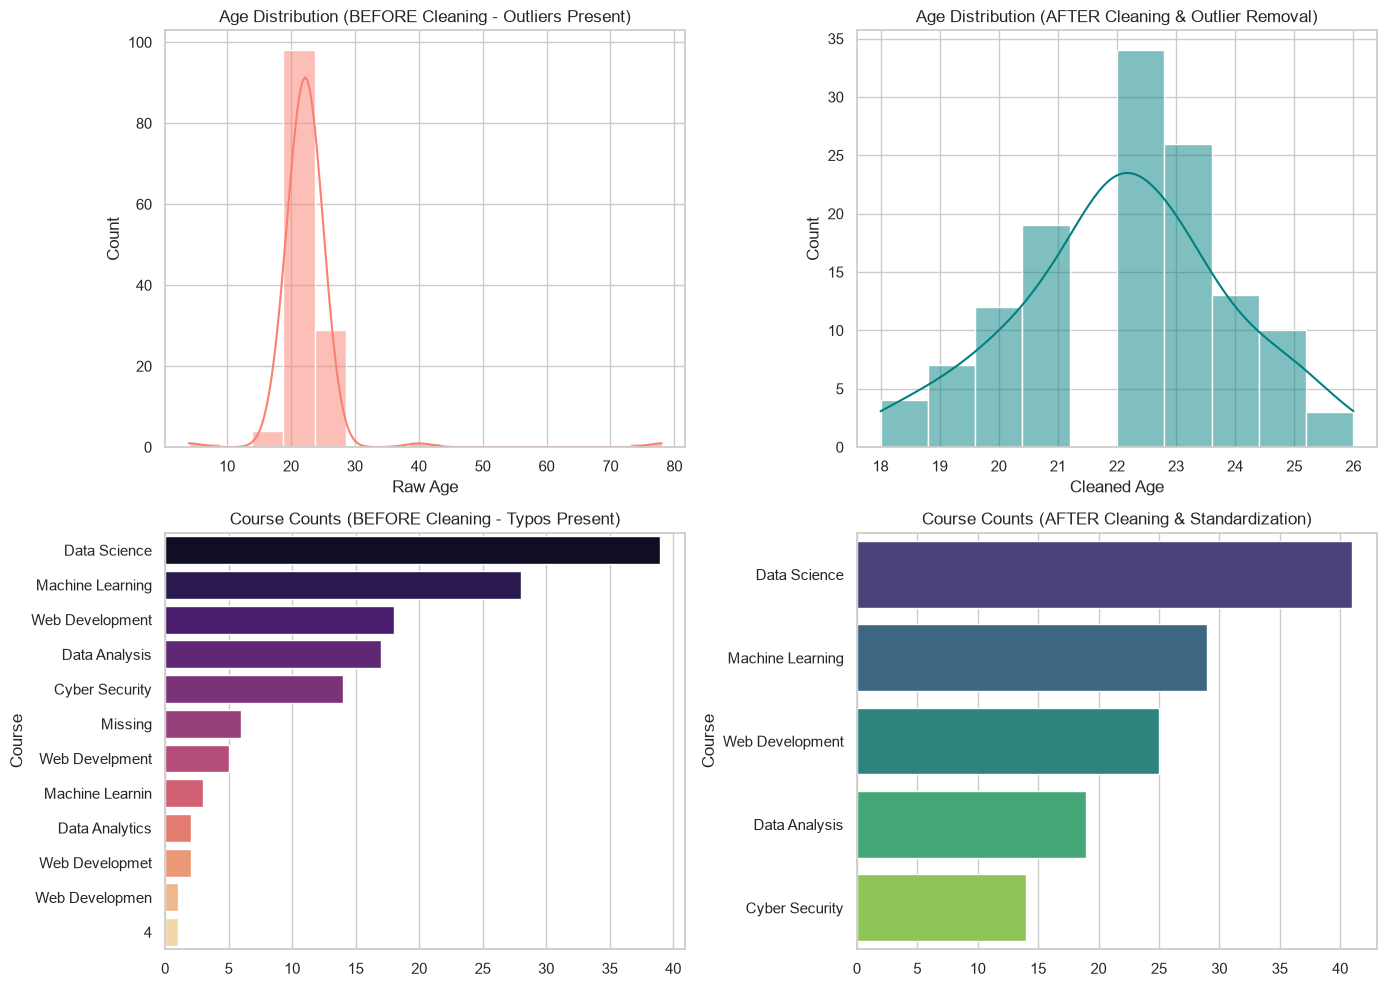

In [14]:
# Visual Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Age Distribution Before vs After Outlier Removal
sns.histplot(df_raw['Age'].apply(clean_age).dropna(), kde=True, ax=axes[0, 0], color='salmon', bins=15)
axes[0, 0].set_title('Age Distribution (BEFORE Cleaning - Outliers Present)')
axes[0, 0].set_xlabel('Raw Age')

sns.histplot(df_clean['Age'], kde=True, ax=axes[0, 1], color='teal', bins=10)
axes[0, 1].set_title('Age Distribution (AFTER Cleaning & Outlier Removal)')
axes[0, 1].set_xlabel('Cleaned Age')

# Plot 2: Course Distribution Before vs After Cleaning
course_counts_before = df_raw['Course'].fillna('Missing').value_counts()
sns.barplot(x=course_counts_before.values, y=course_counts_before.index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Course Counts (BEFORE Cleaning - Typos Present)')

course_counts_after = df_clean['Course'].value_counts()
sns.barplot(x=course_counts_after.values, y=course_counts_after.index, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Course Counts (AFTER Cleaning & Standardization)')

plt.tight_layout()
plt.show()


## 10. Export Cleaned Dataset

Finally, we export the fully preprocessed dataset to `Cleaned_Dataset.csv`.


In [15]:
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned dataset successfully exported to '{cleaned_csv_path}'!")
print(f"Final shape: {df_clean.shape}")


Cleaned dataset successfully exported to 'Cleaned_Dataset.csv'!
Final shape: (128, 22)
